# I) Reference simulation

## 1) Geometry

First, we define the geometry, material distribution, and generate the mesh.

In [1]:
pole_pairs = 6
bundles_per_half_slot = 5

# Generate the corresponding mesh
from utils.geometry import machine_mesh
mesh = machine_mesh(p=pole_pairs, 
                    bundles_per_half_slot=bundles_per_half_slot, 
                    hBundle=1e-3 # 0.25e-3
                    )

print(f"Generated mesh with {mesh.nv} nodes, {mesh.ne} elements")

Generated mesh with 2533 nodes, 4986 elements


In [2]:
# Display the mesh
from ngsolve.webgui import Draw
print("Machine mesh")
Draw(mesh.Curve(2), filename = 'scenes/ref/mesh.html')

Machine mesh


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [3]:
# Display the different material distribution
air = 0
magnet = 1
iron = 2
copper = 3

zones = mesh.MaterialCF({"rotor" : magnet,
                         "core_stator" : iron,
                         "slot.*_bundle.*" : copper,
                         }, default = air)

print("Material distribution")
Draw(zones, mesh,
     settings = {"Objects" : {"Wireframe" : False}},
     filename = "scenes/ref/materials.html")

Material distribution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene

_______
## 2) Physical state computation

### 2.a) Material properties

In [4]:
# Magnetic permeability
mur_iron = 1000

from ngsolve import pi
mu0 = 4e-7 * pi

# Define reluctivity necessary for the magnetic vector-potential formulation
nu = mesh.MaterialCF({"core_stator" : 1 / (mu0 * mur_iron)}, default = 1/mu0) 

# Display relative permeability
print("Relative permeability")
Draw(1/(mu0*nu), mesh,
     settings = {"Objects" : {"Wireframe" : False}},
     filename = "scenes/ref/mu_r.html")

Relative permeability


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene

In [5]:
# Electrical conductivity

sigma_copper = 5.8e7  # S/m
sigma = mesh.MaterialCF({"slot(.*)_bundle.*" : sigma_copper})

# Display conductivity distribution
print("Conductivity (S/m)")
Draw(sigma, mesh,
     settings = {"Objects" : {"Wireframe" : False}},
     filename = "scenes/ref/sigma.html")

Conductivity (S/m)


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene

In [6]:
# Rotating remanence / magnetization

Br_magnets = 1 # remanence in T

# Define magnetization in A/m necessary for the magnetic vector-potential formulation
from utils.physics_symmetric import magnetization_halbach
M = mesh.MaterialCF({"rotor" : magnetization_halbach(br = Br_magnets, p = pole_pairs)}) # A/m

# Display remanence distribution
electric_angle = 0 # angle can be changed, try 90 or 180°
print(f"Remanent flux density (T) at an electric angle of {electric_angle:.0f}°")
from ngsolve import CF, exp
Draw(mu0 * CF(((M[0]*exp(1j*pi/180*electric_angle)).real, 
               (M[1]*exp(1j*pi/180*electric_angle)).real)), mesh,
     vectors = {"grid_size": 40},
     settings = {"Objects" : {"Wireframe" : False, "Surface": False}},
     filename = f"scenes/ref/Br_{electric_angle:.0f}°el.html")

Remanent flux density (T) at an electric angle of 0°


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene

### 2.b) Current supply

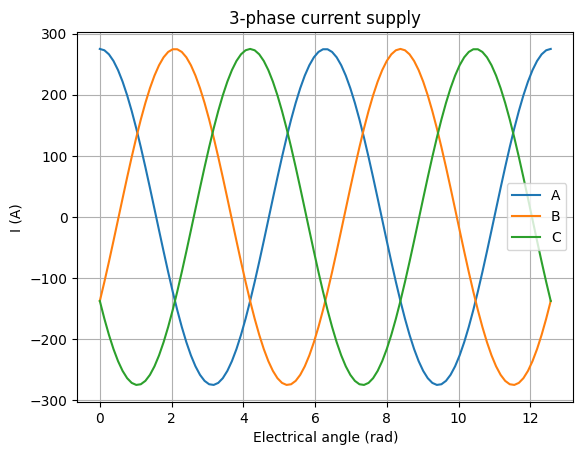

In [7]:
# Define the supply parmeters

Jrms = 10e6          # A/m²
load_angle = 0       # °
frequency = 1000     # Hz

from ngsolve import Integrate
Irms = Jrms * Integrate(1, mesh.Materials("slot11_bundle0"))

# Distribute the current through conductors
from utils.supply import phase_current
phase = phase_current(I_rms=Irms, load_angle=load_angle * pi/180)

# Display the A-B-C currents
import matplotlib.pyplot as plt
import numpy as np
from ngsolve import pi, exp
theta = np.linspace(0, 4*pi, 100)
plt.plot(theta, (phase["Ap"] * exp(1j * theta)).real, label = "A")
plt.plot(theta, (phase["Bp"] * exp(1j * theta)).real, label = "B")
plt.plot(theta, (phase["Cp"] * exp(1j * theta)).real, label = "C")
plt.xlabel("Electrical angle (rad)"); plt.ylabel("I (A)"); 
plt.grid(); plt.legend(); plt.title("3-phase current supply")
plt.show()

In [8]:
# Define the winding arangement
winding_type = "distributed" # "concentrated"

# Distribute the current within the conductors
from utils.supply import winding_arrangement, bundle_arrangement
winding = winding_arrangement(phase = phase, type = winding_type)
bundles = bundle_arrangement(winding = winding, bundles_per_half_slot = bundles_per_half_slot)

# Display current distribution 
electric_angle = 0 # angle can be changed, try 90 or 180
print(f"Current (A) at an electric angle of {electric_angle:.0f}°")
Draw((mesh.MaterialCF(bundles)*exp(1j*pi/180*electric_angle)).real, mesh,
     settings = {"Objects" : {"Wireframe" : False}},
     filename = f"scenes/ref/J_{electric_angle:.0f}°el.html")

Current (A) at an electric angle of 0°


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene

### 2.c) Solve magneto-harmonic problem

#### 2.b.i) Finite element space

In [9]:
# define anti-periodic finite element space with inner and outer Dirichlet boundary conditions
curve_order = 2
fem_order = curve_order
dirichlet_bnd = "shaft|out"

from ngsolve import Periodic, H1
fes = Periodic( H1(mesh.Curve(curve_order), 
                   order = fem_order, 
                   dirichlet = dirichlet_bnd, 
                   complex = True),  [-1]*7 )

print(f"Number of degrees of freedom : {fes.ndof}")

Number of degrees of freedom : 10051


#### 2.b.ii) Solve the problem

In [10]:
from utils.physics_symmetric import solve_magnetoharmonic

result_ref = solve_magnetoharmonic(
    fes = fes, 
    frequency = frequency,
    reluctivity = nu,
    magnetization = M,
    conductivity=sigma,
    supply = bundles)

In [11]:
# Display the flux lines (isovalues of vector potential z-component)

electric_angle = 0
print(f"Magnetic vector potential (T.m) at an electrical angle of {electric_angle:.0f}°")
Draw((result_ref["solution"]["a"]*exp(1j *pi/180 * electric_angle)).real, 
      result_ref["info"]["fes"].mesh,
      settings = {"Objects" : {"Wireframe" : False}},
      filename = f"scenes/ref/A_{electric_angle:.0f}°el.html")

Magnetic vector potential (T.m) at an electrical angle of 0°


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene

In [12]:
from utils.physics import solve_magnetoharmonic as solve_magnetoharmonic_asym

result_ref_asym = solve_magnetoharmonic_asym(
    fes = fes, 
    frequency = frequency,
    reluctivity = nu,
    magnetization = M,
    conductivity=sigma,
    supply = bundles)

In [13]:
from utils.physics_symmetric import solve_magnetoharmonic2

result_ref2 = solve_magnetoharmonic2(
    fes = fes, 
    frequency = frequency,
    reluctivity = nu,
    magnetization = M,
    conductivity=sigma,
    supply = bundles)

In [14]:
# Display the difference
from utils.linalg import L2norm
import ngsolve as ngs
print(L2norm(result_ref["solution"]["a"] - result_ref2["solution"]["a"], mesh))
print(L2norm(result_ref_asym["solution"]["a"] - result_ref2["solution"]["a"], mesh))
Draw(ngs.Norm(result_ref["solution"]["a"] - result_ref2["solution"]["a"]),result_ref["info"]["fes"].mesh)

3.363483987584706e-17
3.7207318246188924e-17


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

_____
## 3) Post-processing

Due to the linear magnetic material assmption, the flux density can be quite high (approximate amplitude of 2T), and is even higher at the corner due to geometrical singularities.

Considering the saturation could reduce he flux amplitude, especially at the corners.

In [15]:
# Flux density

electric_angle = 0
from utils.physics_symmetric import Curl
B = Curl(result_ref["solution"]["a"])
print("Magnetic flux density (T) at an electrical angle of {electric_angle:.0f}°")
Draw((B*exp(1j *pi/180 * electric_angle)).real,
     result_ref["info"]["fes"].mesh,
     vectors={"grid_size" : 50, "offset" : 0.5},
     settings = {"Objects" : {"Wireframe" : False}, "Colormap": {"ncolors":32}},
     filename = f"scenes/ref/B_{electric_angle:.0f}°el.html")

Magnetic flux density (T) at an electrical angle of {electric_angle:.0f}°


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene

In [25]:
# Norm of electric field

from utils.physics_symmetric import electric_field, electric_field2
from utils.physics import electric_field as electric_field_asym
from ngsolve import Norm

e  = electric_field(result_ref)
e2  = electric_field2(result_ref2)
e_asym  = electric_field_asym(result_ref_asym)

print(L2norm(e - e2, mesh))
print(L2norm(e2 - e_asym, mesh))
Draw(Norm(e2), result_ref["info"]["fes"].mesh)

1.1816304423641723e-15
2.00827844331462e-15


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [17]:
# Norm of current density

from utils.physics_symmetric import current_density
from ngsolve import Norm

j  = current_density(result_ref)
print("Current density amplitude (A/m²)")
Draw(Norm(j), result_ref["info"]["fes"].mesh,
     settings = {"Objects" : {"Wireframe" : False}, "Colormap": {"ncolors":32}},
     filename = f"scenes/ref/J.html")

Current density amplitude (A/m²)


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene

In [18]:
# Joule losses

from utils.physics_symmetric import joule_losses

joule_losses_ref = joule_losses(result_ref)
print(f"Reference total Joule losses (phi = 150°): {joule_losses_ref:.2e} W/m")

Reference total Joule losses (phi = 150°): 3.46e+04 W/m


____
## 4) Optimal current angle

We look for the current angle that maximizes the torque. We make a simple exhaustive search with a 10° step size.
Since the geometry and material distribution doesn't change, we can reuse the already decomposed FEM matrix from the reference computation, so the sweep is quite fast.

In [19]:
from utils.physics_symmetric import solve_magnetoharmonic, average_torque, Curl
import numpy as np

load_angle = np.arange(0,180,10)
torque = []
scene = Draw(CF(0), fes.mesh, 
             settings = {"Objects" : {"Wireframe" : False}})
for phi in load_angle:
    phase = phase_current(I_rms=Irms,  load_angle=phi*pi/180)
    winding = winding_arrangement(phase, type = winding_type)
    bundles = bundle_arrangement(winding, bundles_per_half_slot=bundles_per_half_slot)
    result = solve_magnetoharmonic(fes=fes,
                                   reluctivity=nu,
                                   conductivity=sigma,
                                   magnetization=M,
                                   frequency=frequency,
                                   supply=bundles,
                                   Kinv=result_ref["info"]["Kinv"] # to accelerate the computation
                                   )
    scene.Redraw(Norm(Curl(result["solution"]["a"])), result["info"]["fes"].mesh, 
                 settings = {"Objects" : {"Wireframe" : False}, "Colormap" : {"ncolors" : 32}},
                 min = 0, max = 3)
    print(f"Z-component of vector potential (Wb/m for Lz = 1m, {phi = :.0f}°/180°)"+" "*10, end = "\r")
    torque.append(average_torque(result))

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

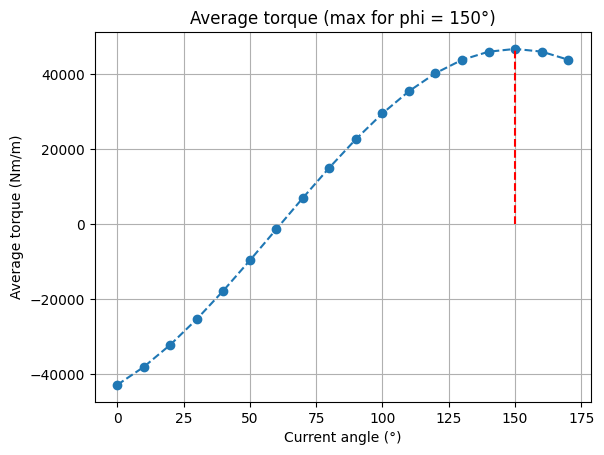

In [20]:
# Selection of the optimal angle
i_max = np.argmax(torque)
phi_max = load_angle[i_max]
torque_max = torque[i_max]

# Display
import matplotlib.pyplot as plt
plt.plot(load_angle, torque, 'o--')
plt.plot([phi_max,phi_max], [0, torque_max], 'r--')
plt.xlabel("Current angle (°)")
plt.ylabel("Average torque (Nm/m)")
plt.title(f"Average torque (max for phi = {phi_max}°)")
plt.grid(); plt.show()

We find that the maximum torque $T_{ref}=46,8\;\text{kNm/m}$ is found at $\varphi = 150°$, and we chose this angle for the minimization of AC losses.

____
## 5) Reference values

Once the optimal load angle is set, we can evaluate the total losses at $1\;\text{KHz}$, and DC losses as a reference.

### 5.a) Computation

In [21]:
phi_ref = 150 # degree
phase_ref = phase_current(I_rms=Irms,  load_angle=phi_ref*pi/180)
winding_ref = winding_arrangement(phase_ref, type = winding_type)
bundles_ref = bundle_arrangement(winding_ref, bundles_per_half_slot=bundles_per_half_slot)

result_ref_AC = solve_magnetoharmonic(fes=fes,
                                   reluctivity=nu,
                                   conductivity=sigma,
                                   magnetization=M,
                                   frequency=frequency,
                                   supply=bundles_ref,
                                   Kinv=result_ref["info"]["Kinv"] # to accelerate the comutation
                                   )

result_ref_DC = solve_magnetoharmonic(fes=fes,
                                   reluctivity=nu,
                                   conductivity=sigma,
                                   magnetization=M,
                                   frequency=frequency / 1e6, # quasi-DC
                                   supply=bundles_ref,
                                   )

### 5.b) Post-processing

In [22]:
total_copper_losses_ref = joule_losses(result_ref_AC)
DC_copper_losses_ref = joule_losses(result_ref_DC)
AC_copper_losses_ref =  total_copper_losses_ref - DC_copper_losses_ref
print(f"Reference total Joule losses (phi = {phi_ref}°): {total_copper_losses_ref:.2e} W/m")
print(f"Reference DC Joule losses (phi = {phi_ref}°): {DC_copper_losses_ref:.2e} W/m ({DC_copper_losses_ref/total_copper_losses_ref*100:.1f} %)")
print(f"Reference AC Joule losses (phi = {phi_ref}°): {AC_copper_losses_ref:.2e} W/m ({AC_copper_losses_ref/total_copper_losses_ref*100:.1f} %)")

Reference total Joule losses (phi = 150°): 3.39e+04 W/m
Reference DC Joule losses (phi = 150°): 1.01e+03 W/m (3.0 %)
Reference AC Joule losses (phi = 150°): 3.28e+04 W/m (97.0 %)


___
## Summary

We find the following reference losses for $\sigma = \sigma_{\text{copper}} = 5.8\times 10^7 S/m$ at $f = 1\;\text{kHz}$:

| Total losses at 1kHz | $P_{ref} = 3.38\times 10^4 \; \text{W/m}$ | 100% |
|---|---|------|
| DC losses | $P_{DC-ref} = 1.01\times 10^2  \; \text{W/m}$ | 3 %   |
| AC losses | $P_{AC-ref} = 3.28\times 10^4  \; \text{W/m}$ | 97 %   |

Reference average torque is $T_{ref} = 46.8 \;\text{kNm/m}$.

It is clear that most of the copper losses comes from the AC losses, which can surely be mitigated using appropriate conductivity and cross sections. These parameters are optimized in the following notebooks:
- [3_single_material_optimization](3_single_material_optimization.ipynb) (optimization of a unique conductivity for the whole winding)
- [4_multi_material_optimization](4_multi_material_optimization.ipynb) (optimization of a different conductivity for each bundle)
- [5_topology_optimization](5_topology_optimization.ipynb) (optimization of the conductivity at each point of the cross-section, so actually the cross-section itself)

Before launching the optimization, we should compute and check the derivative of the copper losses, which is done in [2_taylor_tests](2_taylor_tests.ipynb).